### 1. What Is Random Forest Regression?

Random Forest Regression is an **ensemble learning method** that builds multiple decision trees and merges their predictions to improve accuracy and control overfitting. It’s used for **predicting continuous outcomes**.

### 2. Core Concepts

- **Decision Tree Regression**: A tree splits data into regions and fits a constant value (usually the mean) in each region.
- **Ensemble Learning**: Combines multiple models to produce a stronger overall model.
- **Bagging (Bootstrap Aggregating)**: Each tree is trained on a random subset of the data (with replacement).
- **Random Feature Selection**: At each split, a random subset of features is considered—this adds diversity to the trees.

### 3. How It Works (Step-by-Step)

1. **Data Sampling**: Create multiple bootstrapped datasets from the original training data.
2. **Tree Building**:
   - For each dataset, build a decision tree.
   - At each node, randomly select a subset of features to determine the best split.
3. **Prediction**:
   - For regression, each tree outputs a numerical value.
   - The final prediction is the **average** of all tree outputs.

### 4. Key Parameters

| Parameter             | Description |
|----------------------|-------------|
| `n_estimators`        | Number of trees in the forest |
| `max_features`        | Number of features to consider at each split |
| `max_depth`           | Maximum depth of each tree |
| `min_samples_split`   | Minimum samples required to split a node |
| `min_samples_leaf`    | Minimum samples required at a leaf node |
| `bootstrap`           | Whether to use bootstrapped samples |

### 5. Advantages

-  Handles non-linear relationships well
-  Robust to outliers and noise
-  Reduces overfitting compared to single decision trees
-  Works well with large datasets and high-dimensional data

### 6. Limitations

- Can be computationally intensive
- Less interpretable than a single decision tree
- May not perform well on extrapolation tasks (outside training range)

### 7. Evaluation Metrics

For regression tasks, common metrics include:

- **Mean Squared Error (MSE)**
- **Root Mean Squared Error (RMSE)**
- **Mean Absolute Error (MAE)**
- **R² Score (Coefficient of Determination)**

### 8. Practical Tips

- Normalize or scale features if using models alongside Random Forest.
- Use **feature importance** to understand which variables influence predictions.
- Tune hyperparameters using **Grid Search** or **Random Search** for optimal performance.

### 9. Variants & Extensions

- **Extra Trees (Extremely Randomized Trees)**: More randomness in splits for faster training.
- **Gradient Boosted Trees**: Sequentially builds trees to correct errors of previous ones.
- **Random Forest for Classification**: Same structure, but outputs class labels instead of continuous values.

### 10. Intuition Behind the Magic

Imagine asking 100 experts to estimate the price of a house. Each expert uses different criteria and data. Averaging their estimates gives a more reliable prediction than relying on just one. That’s Random Forest in a nutshell.


**Importing Libraries**

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, learning_curve

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.ensemble import RandomForestRegressor

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Set style
sns.set_style("whitegrid")

**Load dataset**

In [2]:
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="Price")


In [3]:
print(X.shape)

(20640, 8)


In [4]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


**Data cleaning and preprocessing**

In [5]:
print("Dataset Shape:", X.shape)

Dataset Shape: (20640, 8)


In [6]:
print("\nFeature Names:", X.columns)


Feature Names: Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')


In [7]:
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [8]:
# Check missing values
print(X.isnull().sum())

# No missing values in this dataset

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


**Feature Engineering**

In [9]:
# Create a new feature
X["Rooms_per_Household"] = X["AveRooms"] / X["HouseAge"]

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Rooms_per_Household
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,0.170345
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,0.297054
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,0.159387
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,0.111872
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,0.120805


**Train-Test Split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [11]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (16512, 9)
Test shape: (4128, 9)


**Feature Scaling**

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Model Creation and Training**

In [13]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [14]:
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

**Predictions**

In [15]:
y_pred = rf_model.predict(X_test_scaled)

**Model Evaluation**

In [16]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [17]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.3320860447189924
MSE : 0.26288058544164483
RMSE: 0.5127188171323974
R2 Score: 0.7993904271057901


**Hyperparameter Tuning with GridSearchCV**

In [18]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


**Train Final Model**

In [19]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test_scaled)

**Evaluation After Tuning**

In [20]:
print("R2 Score:", r2_score(y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))

R2 Score: 0.8013972920504719
RMSE: 0.510147793879398


**Feature Importance**

In [21]:
importances = best_model.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)
feature_importance 

MedInc                 0.535372
HouseAge               0.028438
AveRooms               0.038100
AveBedrms              0.025814
Population             0.026962
AveOccup               0.135417
Latitude               0.083558
Longitude              0.083564
Rooms_per_Household    0.042775
dtype: float64

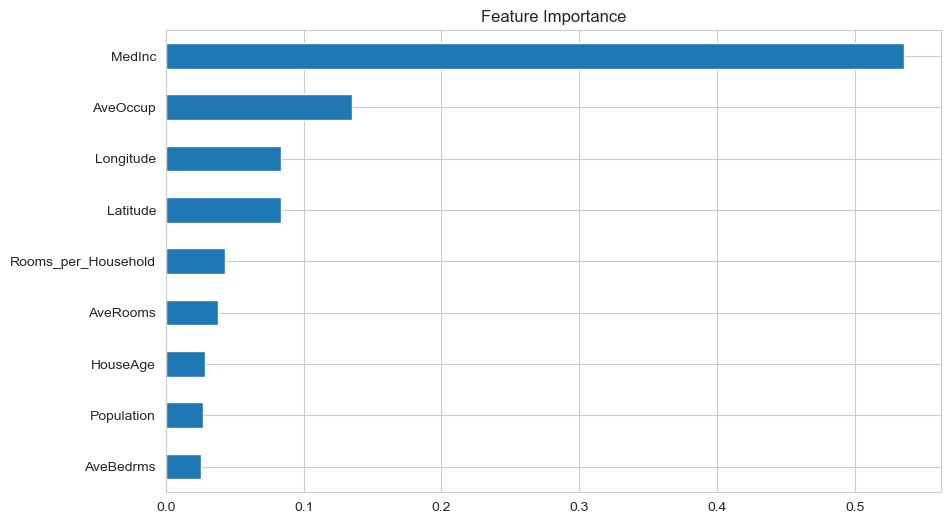

In [22]:
feature_importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Importance")
plt.show()

**Learning Curve**

In [23]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [24]:
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

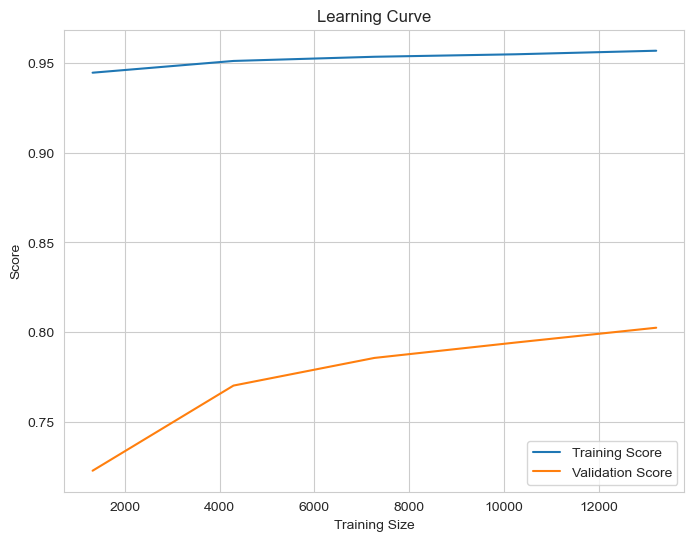

In [25]:
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("Score")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [39]:
# Convert DataFrame to numpy array
X_array = X.values

# Create grid
X_grid = np.arange(X_array[:,0].min(), X_array[:,0].max(), 0.01)
X_grid = X_grid.reshape(-1,1)

# Pad extra features if dataset has more than 1 feature
if X_array.shape[1] > 1:
    X_grid = np.hstack((X_grid, np.zeros((X_grid.shape[0], X_array.shape[1]-1))))


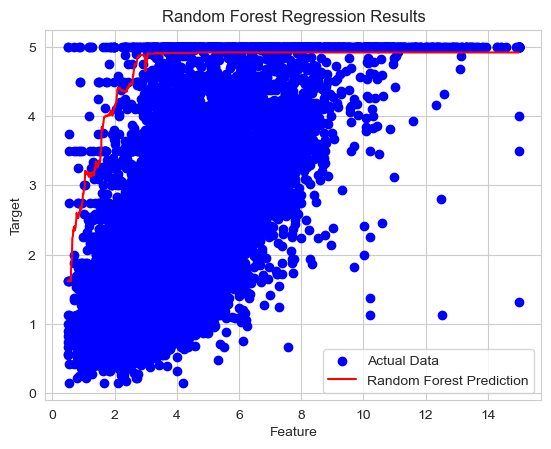

In [42]:
# Plot actual data
plt.scatter(X_array[:,0], y, color='blue', label="Actual Data")

# Plot prediction
plt.plot(X_grid[:,0], rf_model.predict(X_grid), color='red', label="Random Forest Prediction")

plt.title("Random Forest Regression Results")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()

plt.show()